In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from numpy import nan
from pathlib import Path
from chemont import ChemontDict, format_chemont_tree

# 1) Load data

In [24]:
chemont_df = pd.read_csv("data/MSG_test_fold_w_chemont_plus_embedding_pred.tsv", sep="\t")
chemont_df = chemont_df[["identifier", "inchikey", "chemont_tree"]]
format_chemont_tree(chemont_df)

metrics_df = pd.read_csv("data/similarity_measures.tsv", sep="\t")

chemont_df.info()
metrics_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14066 entries, 0 to 14065
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   identifier    14066 non-null  object
 1   inchikey      14066 non-null  object
 2   chemont_tree  14056 non-null  object
dtypes: object(3)
memory usage: 329.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14066 entries, 0 to 14065
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   identifier      14066 non-null  object 
 1   cosine_sim      14066 non-null  float64
 2   euclidean_dist  14066 non-null  float64
dtypes: float64(2), object(1)
memory usage: 329.8+ KB


In [25]:
df = pd.merge(chemont_df, metrics_df, on="identifier")
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14066 entries, 0 to 14065
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   identifier      14066 non-null  object 
 1   inchikey        14066 non-null  object 
 2   chemont_tree    14056 non-null  object 
 3   cosine_sim      14066 non-null  float64
 4   euclidean_dist  14066 non-null  float64
dtypes: float64(2), object(3)
memory usage: 549.6+ KB


,identifier,inchikey,chemont_tree,cosine_sim,euclidean_dist
0,MassSpecGymID0000203,GYSCAQFHASJXRS,"[0, 264, 1813, 1961, 1994]",0.761149,10.036486
1,MassSpecGymID0000204,GYSCAQFHASJXRS,"[0, 264, 1813, 1961, 1994]",0.739842,10.529962
2,MassSpecGymID0000205,GYSCAQFHASJXRS,"[0, 264, 1813, 1961, 1994]",0.767589,9.961919
3,MassSpecGymID0000206,GYSCAQFHASJXRS,"[0, 264, 1813, 1961, 1994]",0.782684,9.603712
4,MassSpecGymID0000208,GYSCAQFHASJXRS,"[0, 264, 1813, 1961, 1994]",0.798874,9.288403
...,...,...,...,...,...
14061,MassSpecGymID0400854,XMSXQFUHVRWGNA,"[0, 462, 1370, 3194, 4445]",0.653316,14.504745
14062,MassSpecGymID0401425,HXIQYSLFEXIOAV,"[1, 423, 453, 555, 555]",0.762149,11.733856
14063,MassSpecGymID0402033,LYUPEIXJYAJCHL,"[0, 12, 259, 1551, 3788]",0.757642,10.278358
14064,MassSpecGymID0402039,PMCAUYATZKXGHU,"[0, 12, 259, 1551, 3788]",0.855012,8.529740


# 2) Translate ChemONT IDs to chemical hierarchy groups

In [26]:
chemont_d = ChemontDict(Path("data/chemont_dictionary.tsv"))

In [49]:
chemical_levels = {
    "superclass": 0,
    "subclass": 1,
    "level3": 2,
    "level4": 3,
    "level5": 4,
}

data_df = df.copy()

for name in chemical_levels.keys():
    data_df[name] = nan
    data_df[name] = data_df[name].astype(object)

In [50]:
data_df["chemont_tree"] = data_df[data_df["chemont_tree"].notnull()]["chemont_tree"].apply(chemont_d.get_names_of_tree)
for i, row in data_df[data_df["chemont_tree"].notna()].iterrows():
    for name, pos in chemical_levels.items():
        data_df.at[i, name] = row["chemont_tree"][pos]

data_df.drop("chemont_tree", axis=1, inplace=True)
data_df.info()
data_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14066 entries, 0 to 14065
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   identifier      14066 non-null  object 
 1   inchikey        14066 non-null  object 
 2   cosine_sim      14066 non-null  float64
 3   euclidean_dist  14066 non-null  float64
 4   superclass      14056 non-null  object 
 5   subclass        14056 non-null  object 
 6   level3          14017 non-null  object 
 7   level4          14017 non-null  object 
 8   level5          14056 non-null  object 
dtypes: float64(2), object(7)
memory usage: 989.1+ KB


,identifier,inchikey,cosine_sim,euclidean_dist,superclass,subclass,level3,level4,level5
0,MassSpecGymID0000203,GYSCAQFHASJXRS,0.761149,10.036486,Organic compounds,Organic acids and derivatives,Peptidomimetics,Depsipeptides,Cyclic depsipeptides
1,MassSpecGymID0000204,GYSCAQFHASJXRS,0.739842,10.529962,Organic compounds,Organic acids and derivatives,Peptidomimetics,Depsipeptides,Cyclic depsipeptides
2,MassSpecGymID0000205,GYSCAQFHASJXRS,0.767589,9.961919,Organic compounds,Organic acids and derivatives,Peptidomimetics,Depsipeptides,Cyclic depsipeptides
3,MassSpecGymID0000206,GYSCAQFHASJXRS,0.782684,9.603712,Organic compounds,Organic acids and derivatives,Peptidomimetics,Depsipeptides,Cyclic depsipeptides
4,MassSpecGymID0000208,GYSCAQFHASJXRS,0.798874,9.288403,Organic compounds,Organic acids and derivatives,Peptidomimetics,Depsipeptides,Cyclic depsipeptides
...,...,...,...,...,...,...,...,...,...
14061,MassSpecGymID0400854,XMSXQFUHVRWGNA,0.653316,14.504745,Organic compounds,Organometallic compounds,Organometalloid compounds,Organosilicon compounds,Organoheterosilanes
14062,MassSpecGymID0401425,HXIQYSLFEXIOAV,0.762149,11.733856,Inorganic compounds,Homogeneous non-metal compounds,Other non-metal organides,Other non-metal sulfides,Other non-metal sulfides
14063,MassSpecGymID0402033,LYUPEIXJYAJCHL,0.757642,10.278358,Organic compounds,Lipids and lipid-like molecules,Prenol lipids,Diterpenoids,Aconitane-type diterpenoid alkaloids
14064,MassSpecGymID0402039,PMCAUYATZKXGHU,0.855012,8.529740,Organic compounds,Lipids and lipid-like molecules,Prenol lipids,Diterpenoids,Aconitane-type diterpenoid alkaloids


# 3) Generate plots

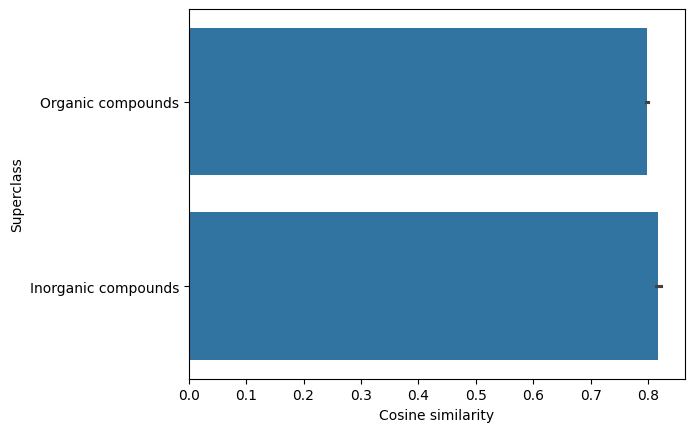

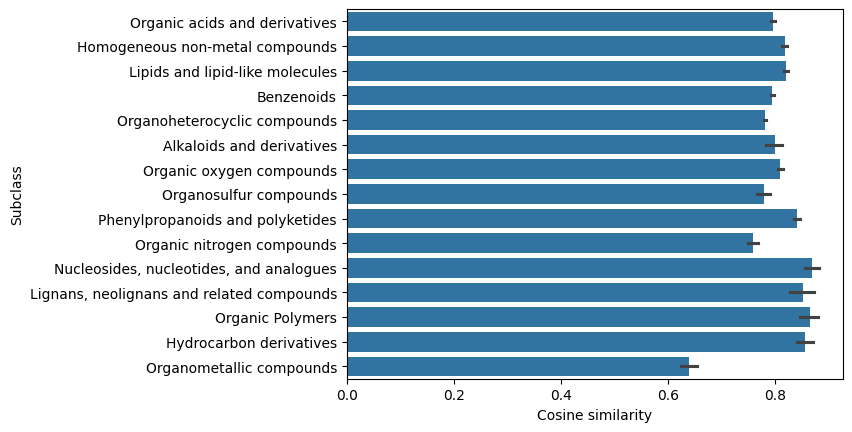

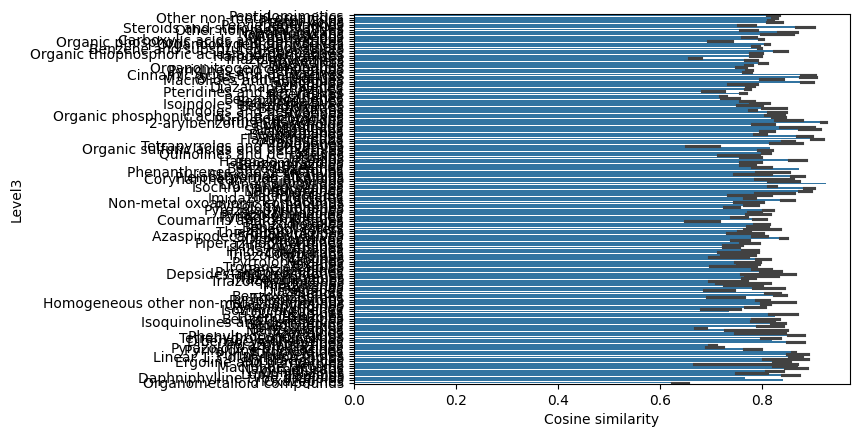

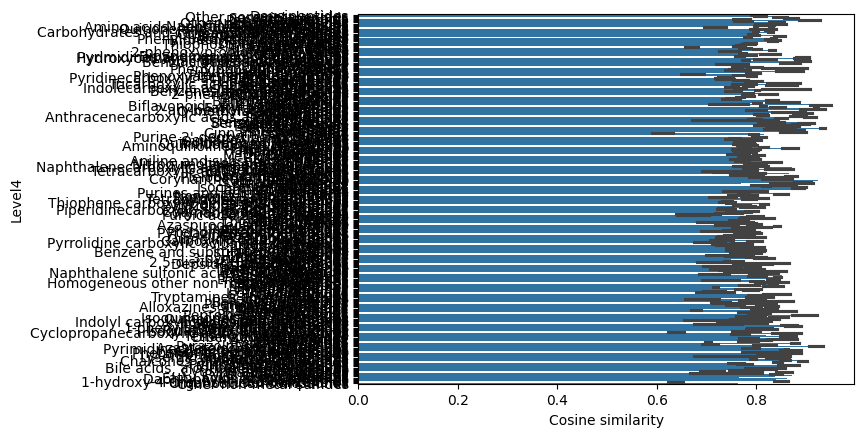

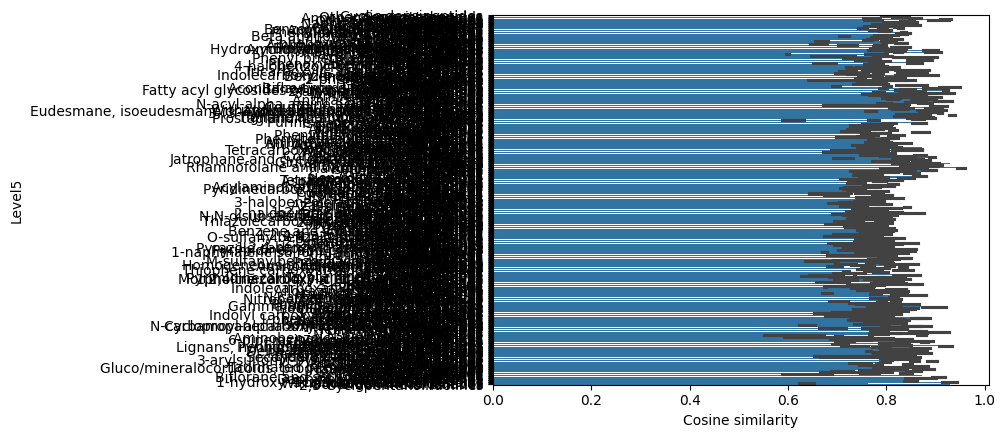

In [62]:
for name in chemical_levels.keys():
    p = sns.barplot(data=data_df, x="cosine_sim", y=name)
    plt.xlabel('Cosine similarity')
    plt.ylabel(name.capitalize())
    plt.show()
